In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
## create signal with two frequencies
## time: sample per sec
dt = 0.001

## dataset samples from 0-1 with sample step 'dt' time
t = np.arange(0, 1, dt)

## two frequencies
## f_raw1 of frequency-50 at 't'
f_raw1 = np.sin(1*np.pi*50*t)

## f_raw2 of frequency-300 at 't'
f_raw2 = np.sin(2*np.pi*300*t)

## clean signal
clean_f = f_raw1+f_raw2

## add noise on the clean_f (clean frequency)
noisy_freq = clean_f + 1.7*np.random.randn(len(t))


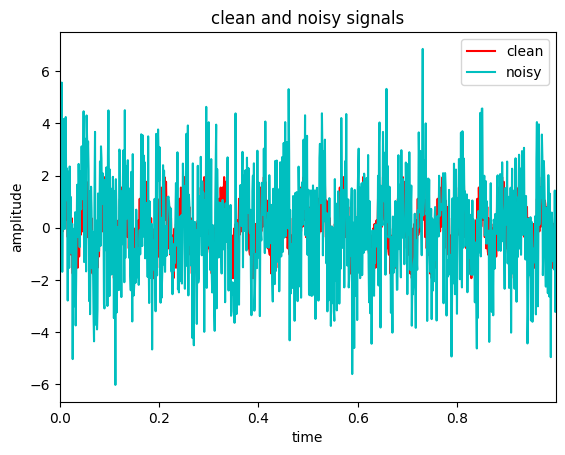

<Figure size 640x480 with 0 Axes>

In [8]:
## plot
plt.plot(t, clean_f, color='r', label='clean')
plt.plot(t, noisy_freq, color='c', label='noisy')
plt.xlim(t[0],t[-1])
plt.xlabel('time')
plt.ylabel('amplitude')
plt.title('clean and noisy signals')
plt.legend()
plt.show()
plt.savefig("plots/clean_noise.png", dpi=150, bbox_inches="tight")

# **About Data**
The above dataset sampled under 0.001 per sec and the time interval would be 0 to 1. Eventually, two signals are sampled e.g f_raw1 and f_raw2, these two signals are combine together to form a clean signal. A lots of gaussian noise with the scale of 1.7 has been added to the signal and generates the noise frequency.

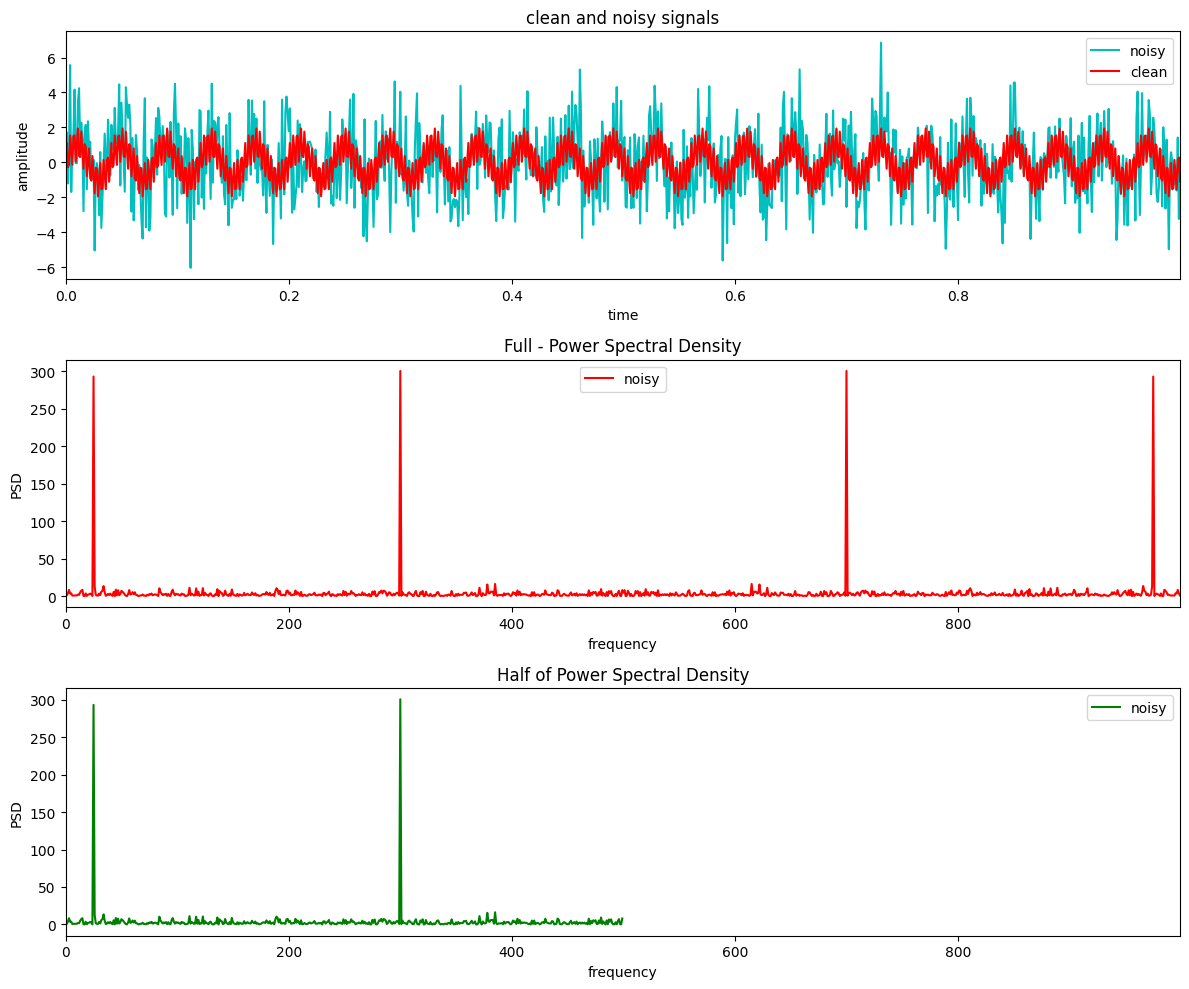

In [ ]:
## compute the Fast Fourier Tansformation
## number of sample(n)/length of datapoints
n = len(t)

## compute the fft on noisy data
fhat = np.fft.fft(noisy_freq, n) ## complex number with magnitude and phase: magnitude tells how important the frequency is? and phase tells you if its more cosine or sine.

## Power spectral Density  (power per frequency)
PSD = fhat * np.conjugate(fhat) / n ## conjugate helps to calculate the real magnitude of the signal

## frequencies vector along x-axis
freq_vec = np.linspace(0, 1/dt, n, endpoint=False) ## same: freq_vec1 = (1/(dt*n)) * np.arange(n)
L = np.arange(1, np.floor(n/2), dtype='int')

## plot
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
axes[0].plot(t, noisy_freq, color = 'c', label='noisy')
axes[0].plot(t, clean_f, color = 'r', label='clean')
axes[0].set_xlim(t[0], t[-1])
axes[0].set_xlabel('time')
axes[0].set_ylabel('amplitude')
axes[0].set_title('clean and noisy signals')
axes[0].legend()


axes[1].plot(freq_vec, PSD, color='r', label ='noisy')
axes[1].set_xlim(freq_vec[0], freq_vec[-1])
axes[1].set_xlabel('frequency')
axes[1].set_ylabel('PSD')
axes[1].set_title('Full - Power Spectral Density')
axes[1].legend()


axes[2].plot(freq_vec[L], PSD[L], color='g', label ='noisy')
axes[2].set_xlim(freq_vec[0], freq_vec[-1])
axes[2].set_xlabel('frequency')
axes[2].set_ylabel('PSD')
axes[2].set_title('Half of Power Spectral Density')
axes[2].legend()

plt.savefig("plots/fft-psd.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()


## **Power Spectral Density (PSD)**:
 It is very closely related to magnitude, but it is not just the magnitude; it is the magnitude squared, spread out across different frequencies, and normalized by frequency bandwidth. If magnitude tells you "how strong the overall signal is?", PSD tells you "how much power is packed into each specific frequency band." Y-axis is the power.



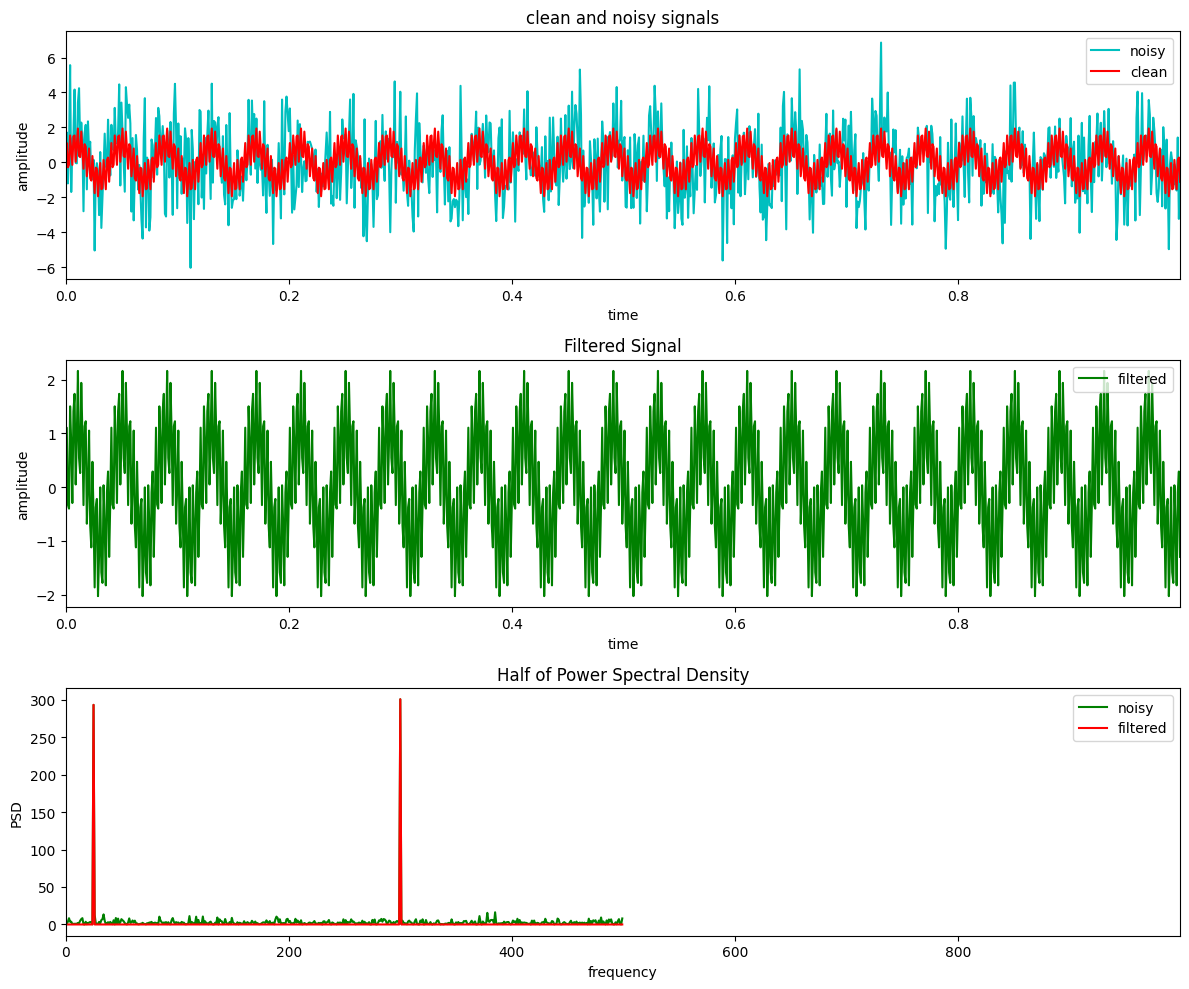

In [13]:
## Use PSD to filter out noisy frequencies
indices = PSD>100 ## find all frequencies with large power

## each rows of PSD has the frequecies values
PSD_clean = PSD * indices ## zero out all psd lower than a threshold value

fhat_clean = fhat * indices ## zero out all small frequency coefficient on Y axis

## perform inverse Fast Fourier Transform to get clean signal
clean_fft = np.fft.ifft(fhat_clean) ## Inverse FFT for filtered time signal

## plot
fig, axes = plt.subplots(3,1, figsize=(12, 10))
axes[0].plot(t, noisy_freq, color = 'c', label='noisy')
axes[0].plot(t, clean_f, color = 'r', label='clean')
axes[0].set_xlim(t[0], t[-1])
axes[0].set_xlabel('time')
axes[0].set_ylabel('amplitude')
axes[0].set_title('clean and noisy signals')
axes[0].legend()

axes[1].plot(t, clean_fft, color='g', label ='filtered')
axes[1].set_xlim(t[0], t[-1])
axes[1].set_xlabel('time')
axes[1].set_ylabel('amplitude')
axes[1].set_title('Filtered Signal')
axes[1].legend()

axes[2].plot(freq_vec[L], PSD[L], color='g', label ='noisy')
axes[2].plot(freq_vec[L], PSD_clean[L], color='r', label ='filtered')
axes[2].set_xlim(freq_vec[0], freq_vec[-1])
axes[2].set_xlabel('frequency')
axes[2].set_ylabel('PSD')
axes[2].set_title('Half of Power Spectral Density')
axes[2].legend()
plt.savefig("plots/fft-psd-filtered-signal.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()
